### 1. Limites de l'Entropie de Shannon
**Objectif :** Démontrer l'obsolescence de l'entropie mathématique comme critère exclusif d'évaluation de la robustesse.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Configuration esthétique pour un rendu "Rapport / Présentation"
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

# 1. Chargement des données
df = pd.read_csv("../processed/passwords_processed.csv")

# 2. Chargement du Dictionnaire (Nettoyé)
corpus = pd.read_csv("../Dictionnaries/processed/linguistic_dictionary.csv")
corpus['token'] = corpus['token'].astype(str).str.lower().str.strip()

# Création de sets rapides pour la recherche
words_set = set(corpus[corpus['category'] == 'word']['token'])
weak_set = set(corpus[corpus['category'] == 'weak_pwd']['token'])

print(f"✅ Dataset : {len(df)} mots de passe chargés.")

✅ Dataset : 99923 mots de passe chargés.


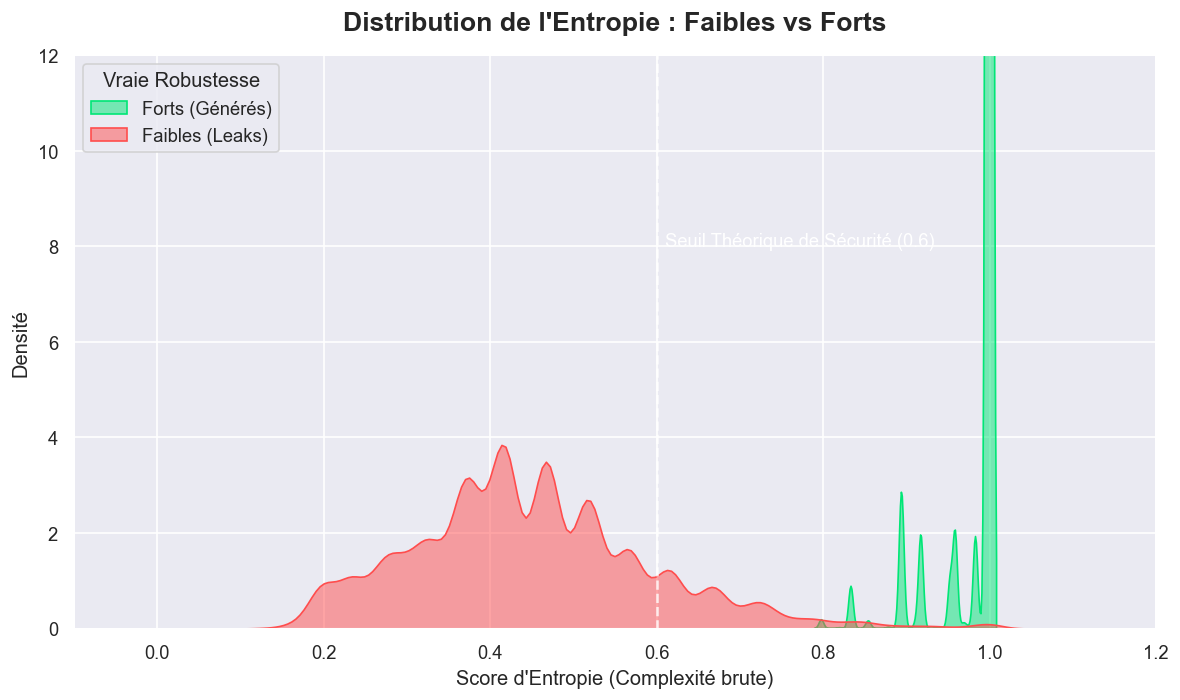

In [64]:
plt.figure(figsize=(10, 6))

# On trace la densité de l'entropie pour les deux classes
sns.kdeplot(data=df, x='entropy', hue='label', fill=True, 
            palette=["#ff4d4d", "#00e676"], alpha=0.5, common_norm=False)

plt.title("Distribution de l'Entropie : Faibles vs Forts", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Score d'Entropie (Complexité brute)", fontsize=12)
plt.ylabel("Densité", fontsize=12)

# Lignes de référence (Passées en BLANC pour le thème sombre)
plt.axvline(x=0.6, color='white', linestyle='--', alpha=0.8)
plt.text(0.61, 8, 'Seuil Théorique de Sécurité (0.6)', color='white', fontsize=11)

# Zoom pour écraser l'aiguille verte et bien voir la courbe rouge
plt.ylim(0, 12)
plt.xlim(-0.1, 1.2)

# Modification de la légende
plt.legend(title='Vraie Robustesse', labels=['Forts (Générés)', 'Faibles (Leaks)'])

plt.tight_layout()
plt.show()

### Analyse des Résultats : Le Mythe de l'Entropie

Ce graphique met en évidence la faille fondamentale des validateurs de mots de passe classiques. En zoomant sur la distribution de la complexité, deux phénomènes majeurs apparaissent :

* **Le "Bruit Parfait" (Courbe Verte) :** L'algorithme de génération forte (CSPRNG) produit une entropie maximale et constante (bloquée à 1.0). La densité est si forte qu'elle sort volontairement du cadre du graphique, prouvant l'efficacité mathématique de l'aléatoire pur.
* **La Zone de Danger (Courbe Rouge à droite de la ligne pointillée) :** L'élément le plus critique de cette analyse se situe après le seuil de 0.6. Une masse très claire de mots de passe humains (issus de la fuite RockYou) franchit allègrement le seuil théorique de sécurité. 

**Conclusion Technique pour le projet :** Un système de cybersécurité qui se baserait uniquement sur un score mathématique (comme la longueur ou l'entropie de Shannon) validerait automatiquement toutes les "failles humaines" situées dans cette zone rouge. Ces mots de passe valident les critères de complexité, mais utilisent des schémas cognitifs prévisibles qui les rendent vulnérables aux attaques par dictionnaire ou force brute intelligente. 

Ce constat justifie techniquement l'abandon des règles classiques au profit d'une **architecture hybride par Intelligence Artificielle**, seule capable de détecter l'intention et la structure sémantique derrière une chaîne de caractères.

### 2. Empreinte Humaine et Prédictibilité (Analyse N-Grammes)
**Objectif :** Visualiser les schémas cognitifs et biomécaniques (frappe clavier) impliqués dans la création de mots de passe.

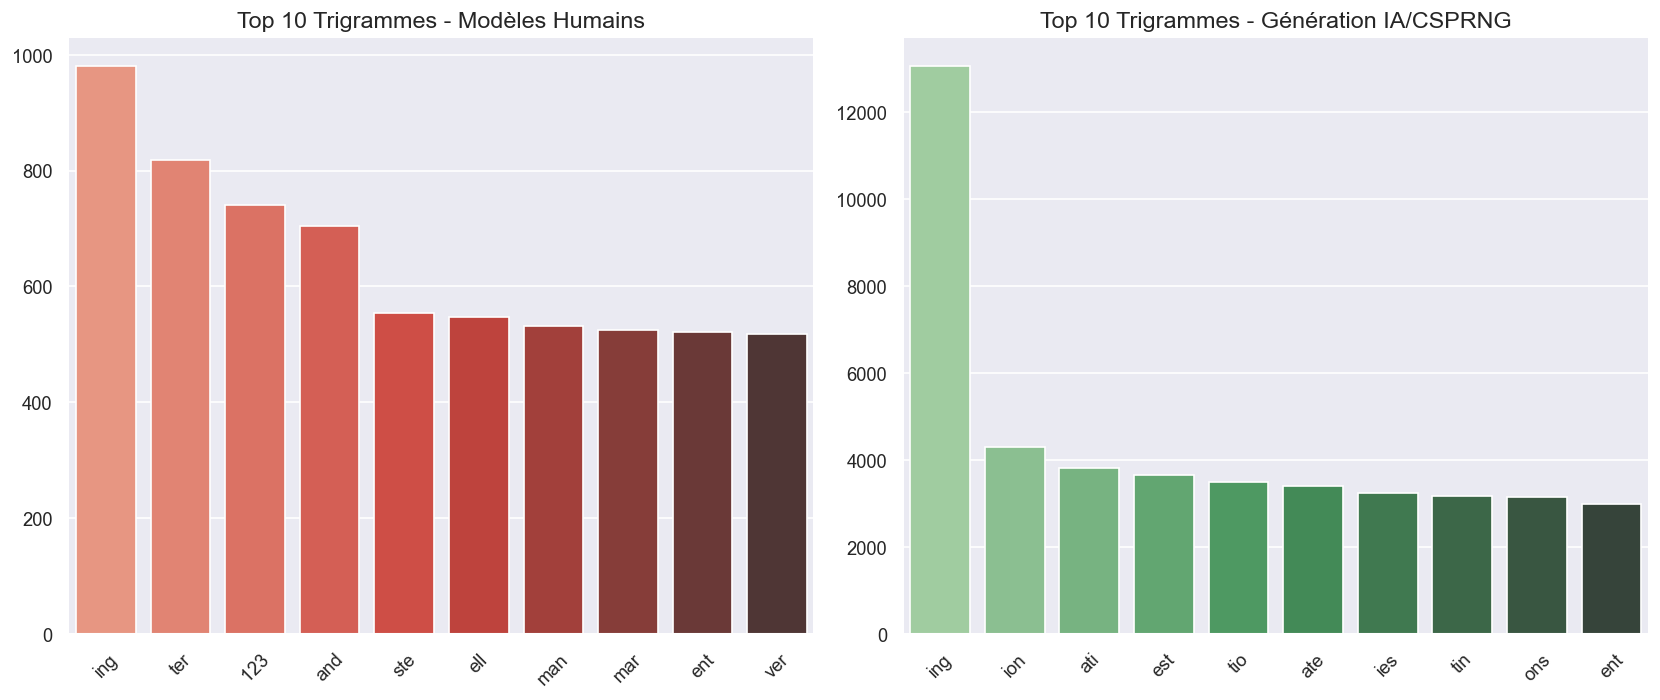

In [65]:
def get_ngrams(text_series, n=3, top_k=10):
    all_ngrams = [str(pwd).lower()[i:i+n] for pwd in text_series for i in range(len(str(pwd))-n+1) if len(str(pwd)) >= n]
    return Counter(all_ngrams).most_common(top_k)

weak_tri = get_ngrams(df[df['label']==0]['password'])
strong_tri = get_ngrams(df[df['label']==1]['password'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trigrammes Faibles
x1, y1 = zip(*weak_tri)
sns.barplot(x=list(x1), y=list(y1), ax=axes[0], hue=list(x1), legend=False, palette="Reds_d")
axes[0].set_title("Top 10 Trigrammes - Modèles Humains", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Trigrammes Forts
x2, y2 = zip(*strong_tri)
sns.barplot(x=list(x2), y=list(y2), ax=axes[1], hue=list(x2), legend=False, palette="Greens_d")
axes[1].set_title("Top 10 Trigrammes - Génération IA/CSPRNG", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Analyse des Résultats : Biais Cognitifs vs Passphrases

L'analyse fréquentielle des N-Grammes (séquences de 3 caractères) révèle une divergence fondamentale dans la structure des mots de passe :

* **L'Empreinte Humaine (Graphique de gauche) :** Les mots de passe compromis sont saturés de biais prédictibles. La présence massive de la suite clavier `123` et de racines de prénoms (`ste`, `mar`) illustre la paresse cognitive et biomécanique des utilisateurs.
* **Le paradigme Diceware (Graphique de droite) :** La forte présence de suffixes linguistiques (`ing`, `ion`, `ati`) dans les mots de passe forts s'explique par l'utilisation d'algorithmes de type Diceware (Passphrases). Si ces mots de passe respectent la phonétique naturelle pour être mémorisables par l'humain, leur longueur et l'aléatoire au niveau des mots les rendent impossibles à bruteforcer. 

**Conclusion Technique :** Les humains insèrent des motifs de substitution et des suites logiques (123) que les générateurs forts n'utilisent jamais. C'est cette "signature" humaine que nos modèles de Deep Learning vont devoir apprendre à traquer pour démasquer les secrets vulnérables.

### 3. Quantification des Biais Structurels
**Objectif :** Mesurer la prévalence des heuristiques de mémorisation humaines.

C:\Users\steph\AppData\Local\Temp\ipykernel_7900\4230061358.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_date'] = df['password'].astype(str).str.contains(r'(19|20)\d{2}', regex=True)
C:\Users\steph\AppData\Local\Temp\ipykernel_7900\4230061358.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_repetition'] = df['password'].astype(str).str.contains(r'(.)\1{2,}', regex=True)


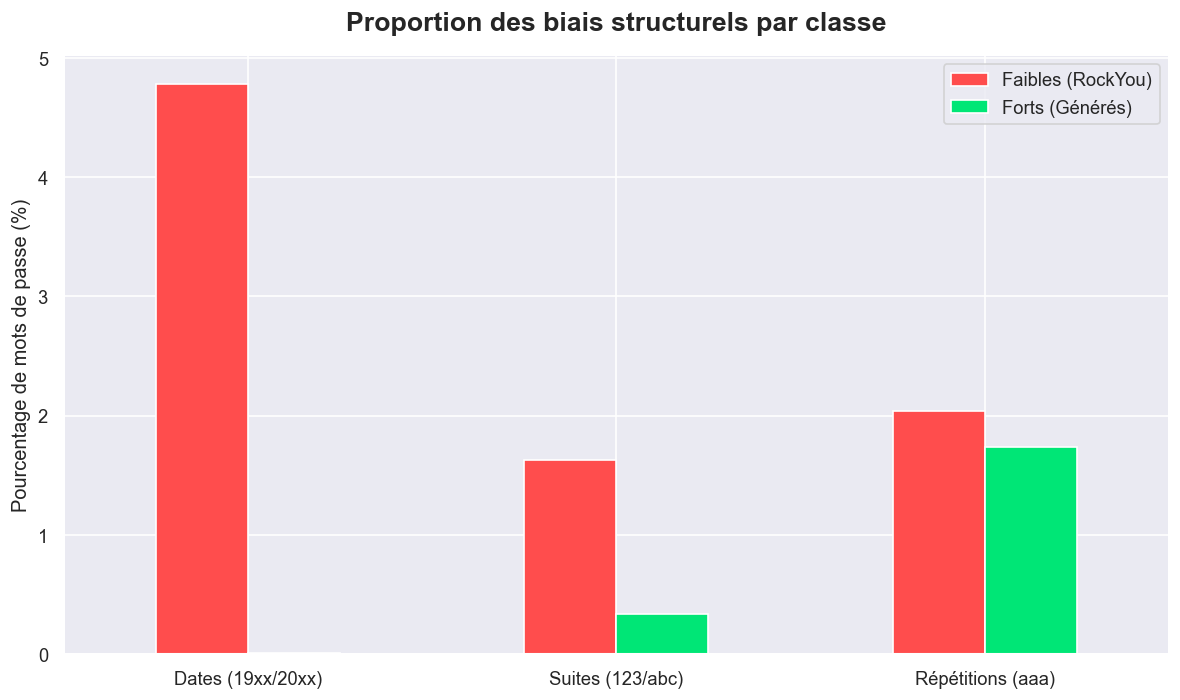

In [66]:
# Fonction vectorisée rapide
df['has_date'] = df['password'].astype(str).str.contains(r'(19|20)\d{2}', regex=True)
df['has_sequence'] = df['password'].astype(str).str.lower().str.contains(r'123|abc|qwe|aze', regex=True)
df['has_repetition'] = df['password'].astype(str).str.contains(r'(.)\1{2,}', regex=True)

# Calcul des pourcentages
patterns = ['has_date', 'has_sequence', 'has_repetition']
summary = df.groupby('label')[patterns].mean() * 100

# Graphique
summary.T.plot(kind='bar', figsize=(10, 6), color=["#ff4d4d", "#00e676"])
plt.title("Proportion des biais structurels par classe", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Pourcentage de mots de passe (%)", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=["Dates (19xx/20xx)", "Suites (123/abc)", "Répétitions (aaa)"], rotation=0)
plt.legend(["Faibles (RockYou)", "Forts (Générés)"])

plt.tight_layout()
plt.show()

### Analyse des Résultats : Empreintes Structurelles et Illusion Aléatoire

L'extraction par expressions régulières (Regex) des motifs structurels confirme les limites de la génération humaine face à l'aléatoire cryptographique :

* **Marqueurs Humains Forts (Dates et Séquences) :** L'intégration d'années (19xx/20xx) et de suites logiques (123, abc) est exclusive aux mots de passe compromis. L'humain compense l'exigence de longueur en concaténant des données personnelles mémorisables ou en glissant sur le clavier.
* **Le Paradoxe des Répétitions :** La proportion de caractères répétés consécutivement (ex: `aaa`) est équivalente dans les deux classes (~2%). Cela démontre l'illusion des séries (*Clustering Illusion*) : un algorithme parfaitement aléatoire génère naturellement des répétitions sur de longues séquences. L'humain, cherchant à simuler la complexité, a tendance à les éviter consciemment.

**Conclusion Technique :** Les expressions régulières ciblant les années et les séquences clavier constituent des *features* à haute valeur discriminante pour les modèles de Machine Learning. À l'inverse, la répétition de caractères ne peut plus être considérée par les validateurs de mots de passe comme une preuve de faiblesse fiable.

### 4. Détection des Anomalies
**Objectif :** Isoler la population cible du modèle hybride : les secrets mathématiquement robustes mais humainement prévisibles.

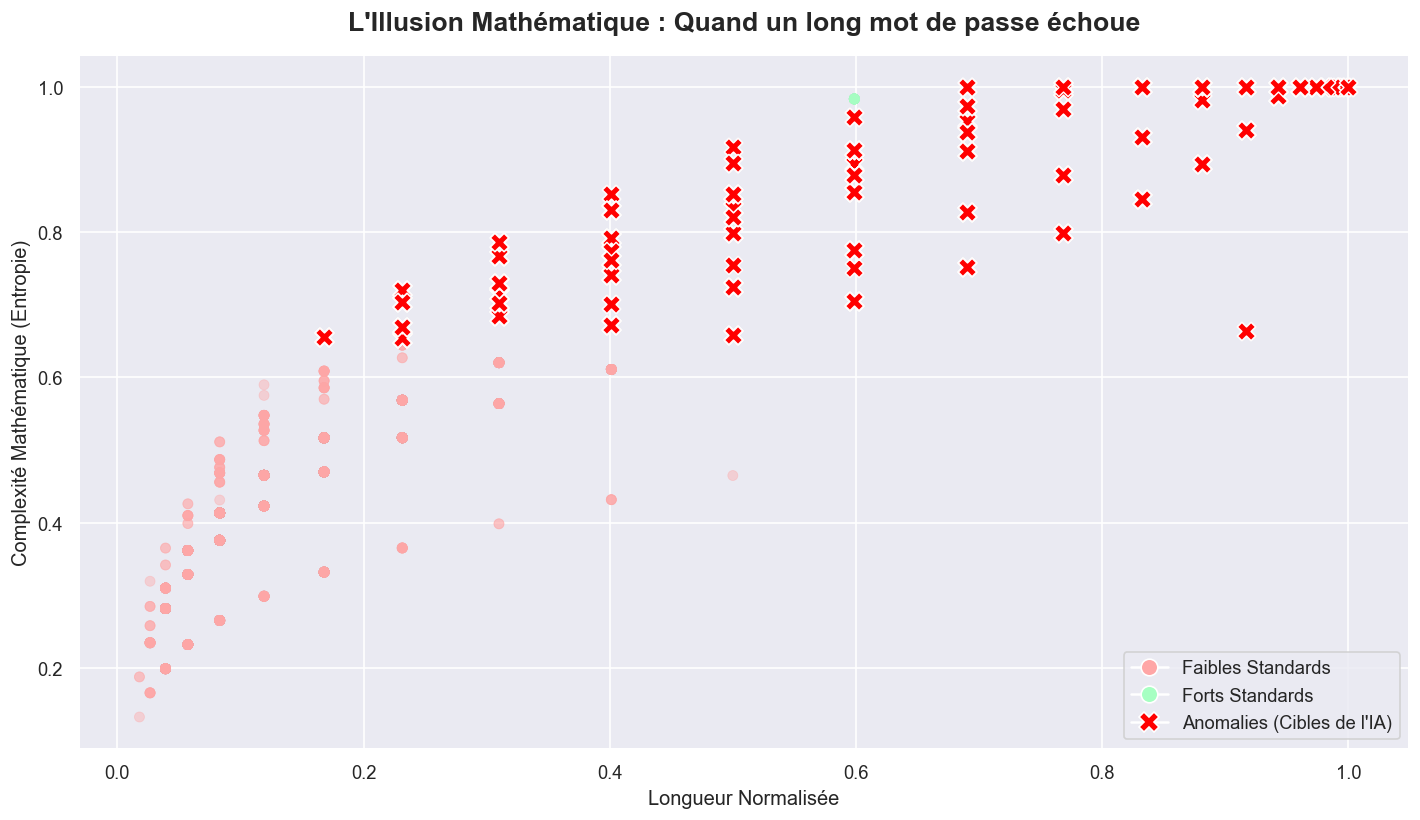


Nombre d'anomalies détectées : 4698
Exemples de Faux Forts (Haute Entropie mais crackés) :


,password,entropy
13,recyclability0,0.723790
42,adjud!ca7es,0.669621
68,b!0graph!3s,0.669621
74,twilightrocks15,0.775489
106,nonpopulousness,0.705066


In [67]:
# On cible les mots de passe Crackés (0) mais avec une entropie dans le top 25% global
# --- CORRECTION DU SEUIL ---
# On cible les mots de passe Crackés (0) qui trompent les calculs (entropie > 0.65)
seuil_absolu = 0.65 
anomalies = df[(df['label'] == 0) & (df['entropy'] > seuil_absolu)]

plt.figure(figsize=(12, 7))

# Échantillon de fond pour ne pas surcharger le graphique
sample_df = df.sample(min(3000, len(df)))
sns.scatterplot(data=sample_df, x='length_norm', y='entropy', hue='label', 
                palette=["#ffa6a6", "#a6ffc2"], alpha=0.4, edgecolor=None)

# Superposition des anomalies
sns.scatterplot(data=anomalies, x='length_norm', y='entropy', 
                color='red', marker='X', s=120, label='Failles Humaines (Faux Forts)', zorder=5)

import matplotlib.lines as mlines

# ... (le reste du code au-dessus ne change pas) ...

plt.title("L'Illusion Mathématique : Quand un long mot de passe échoue", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Longueur Normalisée", fontsize=12)
plt.ylabel("Complexité Mathématique (Entropie)", fontsize=12)

# --- CORRECTION : Création d'une légende manuelle robuste ---
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ffa6a6', markersize=10, label='Faibles Standards'),
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='#a6ffc2', markersize=10, label='Forts Standards'),
    mlines.Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markersize=12, label="Anomalies (Cibles de l'IA)")
]

plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Affichage sécurisé du Top 5
print(f"\nNombre d'anomalies détectées : {len(anomalies)}")
if not anomalies.empty:
    print("Exemples de Faux Forts (Haute Entropie mais crackés) :")
    display(anomalies[['password', 'entropy']].head(5))
else:
    print("Aucune anomalie trouvée à ce seuil d'entropie.")

### Analyse Visuelle et Étude de Cas

Ce bloc de résultats croise l'analyse visuelle de notre dataset avec des extractions concrètes. Le graphique de dispersion évalue les deux métriques reines de la sécurité classique : la longueur normalisée et la complexité mathématique (entropie). Si la corrélation globale est logique, l'analyse révèle des aberrations critiques.

**1. L'Illusion Mathématique (Le Graphique)**
* En haut à droite du graphique se trouve théoriquement la zone de sécurité maximale. C'est effectivement ici que se concentrent les secrets algorithmiques parfaits (points verts).
* **Les Anomalies :** L'application d'un filtre strict (entropie > 0.65) isole les "Faux Forts" ciblés par notre IA. Ces mots de passe, pourtant issus de fuites réelles, ont réussi à se hisser dans le cadran de haute sécurité en abusant des règles de calcul.

**2. Anatomie des Failles (Le Tableau d'Extraction)**
Le tableau généré sous le graphique confirme l'ampleur du problème : près de 4700 mots de passe compromis trompent ainsi les mathématiques. L'analyse du Top 5 révèle les trois grands stratagèmes humains :
* **L'illusion de la longueur (`nonpopulousness`, `recyclability0`) :** Des mots très longs issus du dictionnaire gonflent artificiellement l'entropie, mais n'offrent aucune résistance face à une attaque par dictionnaire classique.
* **La concaténation prévisible (`twilightrocks15`) :** L'association de mots communs suivie d'un suffixe numérique standard.
* **Le Leet Speak basique (`b!0graph!3s`, `adjud!ca7es`) :** L'insertion de symboles (`!` pour `i`, `0` pour `o`) simule une forte diversité de caractères. Si cela valide les critères de complexité des sites web, c'est instantanément contourné par les règles de dérivation des outils de piratage modernes (ex: Hashcat).

**Conclusion Technique pour le Projet :** Un validateur standard de site web accorderait ces mots de passe. Ces résultats prouvent définitivement que la simple complexité des caractères est devenue obsolète. C'est pour déjouer cette supercherie et bloquer ces menaces invisibles que notre Méta-Modèle intègre l'analyse sémantique et la reconnaissance de motifs par Deep Learning.

### 5. Explicabilité du Modèle
**Objectif :** Auditer le processus décisionnel de l'expert Machine Learning (Random Forest).

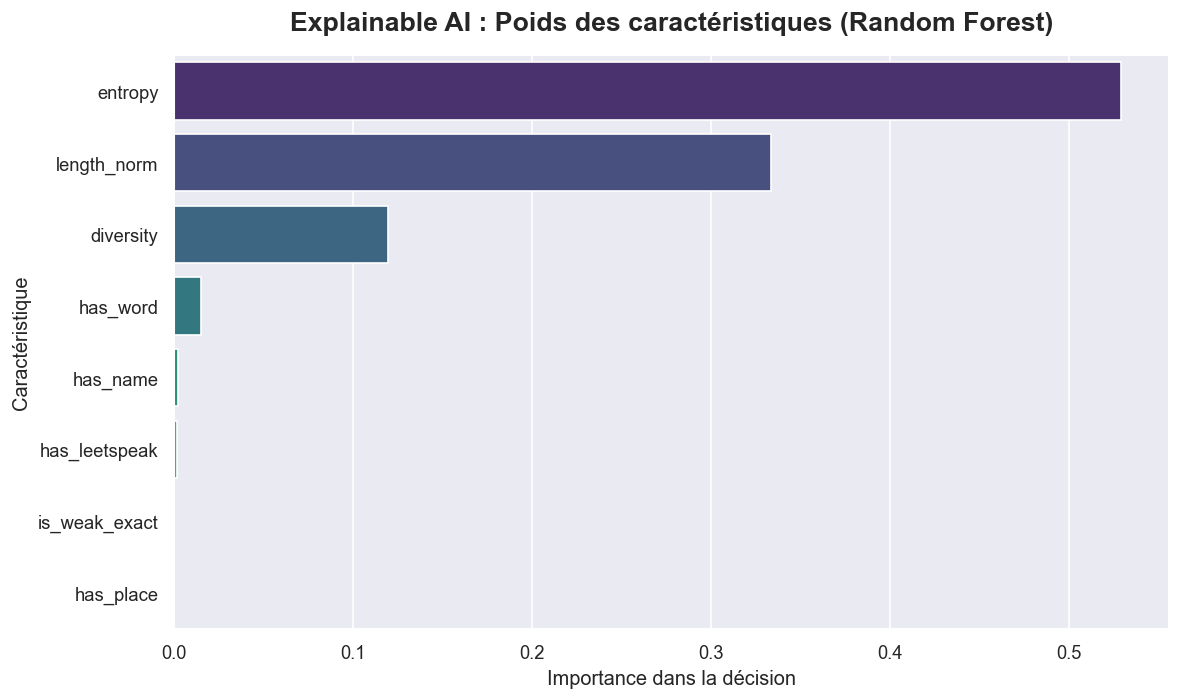

In [68]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
from pathlib import Path

# --- 1. Masquage des avertissements (Nettoyage visuel) ---
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# --- 2. Résolution dynamique du chemin ---
current_dir = Path(os.getcwd()).resolve()
BASE_DIR = current_dir

# Le script remonte en arrière jusqu'à trouver le dossier "backend"
while not (BASE_DIR / "backend").exists() and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

MODEL_DIR = BASE_DIR / "backend" / "app" / "models"
# --- 3. Chargement du modèle ---
rf_model = joblib.load(MODEL_DIR / "random_forest.pkl")
importances = rf_model.feature_importances_

# --- CORRECTION : Les 8 features exactes utilisées lors de l'entraînement ---
feature_names = [
    'length_norm', 
    'diversity', 
    'entropy', 
    'is_weak_exact', 
    'has_word', 
    'has_name', 
    'has_place', 
    'has_leetspeak' # <- L'élément qui manquait
] 

# --- 4. Création du DataFrame et tri ---
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# --- 5. Visualisation ---
plt.figure(figsize=(10, 6))

# Ajout de hue='Feature' et legend=False pour conformité Seaborn >= 0.13
sns.barplot(
    data=df_importance, 
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    palette="viridis", 
    legend=False
)

plt.title("Explainable AI : Poids des caractéristiques (Random Forest)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Importance dans la décision", fontsize=12)
plt.ylabel("Caractéristique", fontsize=12)

plt.tight_layout()
plt.show()

# Réactivation des avertissements (Bonne pratique)
warnings.resetwarnings()

### Analyse de l'Explicabilité (XAI)

L'extraction de l'importance des caractéristiques (*Feature Importance*) du Random Forest met en lumière le processus décisionnel d'un modèle d'apprentissage supervisé standard. Les résultats révèlent un biais algorithmique majeur :

* **Domination Mathématique :** L'entropie (53%), la longueur normalisée (33%) et la diversité (12%) monopolisent la quasi-totalité de l'arbre de décision.
* **Effacement Sémantique :** Les variables d'ingénierie sociale (dictionnaire, prénoms, Leet Speak) ont un poids négligeable, proche de zéro.

**Conclusion Technique :** Face à un dataset contenant des secrets générés algorithmiquement (CSPRNG), le Random Forest choisit le chemin de moindre résistance. Le signal mathématique est si fort qu'il occulte les anomalies humaines. Le modèle se comporte ainsi comme un validateur statique traditionnel : performant globalement, mais structurellement aveugle aux "Faux Forts". Ce diagnostic valide la nécessité absolue d'une architecture hybride, confiant l'analyse séquentielle à des réseaux de neurones profonds (Deep Learning) insensibles à ce biais statistique.

### 6. Validation de l'Architecture Hybride
**Objectif :** Justifier l'approche par Stacking et évaluer la pertinence de chaque réseau de neurones.

C:\Users\steph\AppData\Local\Temp\ipykernel_7900\2729886297.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_meta, x='Confiance', y='Expert', palette="magma")


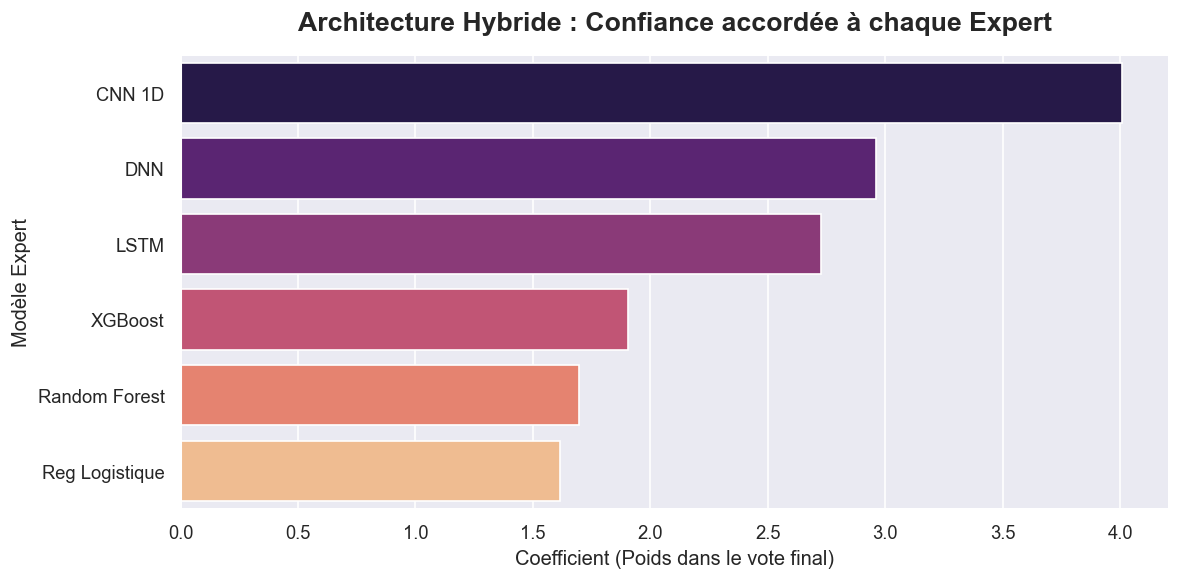

In [69]:
# 1. Chargement du Méta-Modèle (Régression Logistique du Stacking)
meta_model = joblib.load(MODEL_DIR / "hybrid_meta.pkl")

# 2. Récupération des coefficients assignés à chaque expert
# L'ordre correspond à ton train_hybrid.py : ['rf', 'xgb', 'log', 'cnn', 'lstm', 'dnn']
experts = ['Random Forest', 'XGBoost', 'Reg Logistique', 'CNN 1D', 'LSTM', 'DNN']
poids = meta_model.coef_[0]

df_meta = pd.DataFrame({'Expert': experts, 'Confiance': poids})
df_meta = df_meta.sort_values(by='Confiance', ascending=False)

# 3. Visualisation
plt.figure(figsize=(10, 5))
sns.barplot(data=df_meta, x='Confiance', y='Expert', palette="magma")

plt.title("Architecture Hybride : Confiance accordée à chaque Expert", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Coefficient (Poids dans le vote final)", fontsize=12)
plt.ylabel("Modèle Expert", fontsize=12)

plt.tight_layout()
plt.show()

### Validation de l'Hybridation : Poids Décisionnels du Méta-Modèle

L'extraction des coefficients de la Régression Logistique (agissant comme Méta-Modèle dans notre architecture de Stacking) permet de quantifier la confiance accordée à chaque expert lors du vote prédictif final.

* **Prédominance de l'Apprentissage Profond (Deep Learning) :** Le réseau convolutif (CNN 1D) écrase le reste de l'architecture avec un coefficient de 4.0, suivi par le DNN et le LSTM. Cette hiérarchie démontre la supériorité des réseaux de neurones pour l'extraction de caractéristiques spatiales (motifs clavier) et séquentielles (habitudes linguistiques) indétectables par de simples statistiques.
* **Dévaluation du Machine Learning Classique :** XGBoost et le Random Forest obtiennent des coefficients inférieurs à la moitié de celui du CNN. Le Méta-Modèle a mathématiquement identifié leurs difficultés face aux faux forts et a automatiquement réduit leur influence lors de l'arbitrage.

**Conclusion Technique :**
Le principe de l'Ensemble Learning est ici validé empiriquement. Le Méta-Modèle utilise les algorithmes de Machine Learning classique pour la validation mathématique de base, mais s'en remet à l'Intelligence Artificielle de pointe (CNN/LSTM) pour arbitrer les cas complexes et identifier les biais cognitifs humains.

### 7. Performance Comparative globale
**Objectif :** Mesurer le gain de classification concret apporté par l'arbitrage du Méta-Modèle.

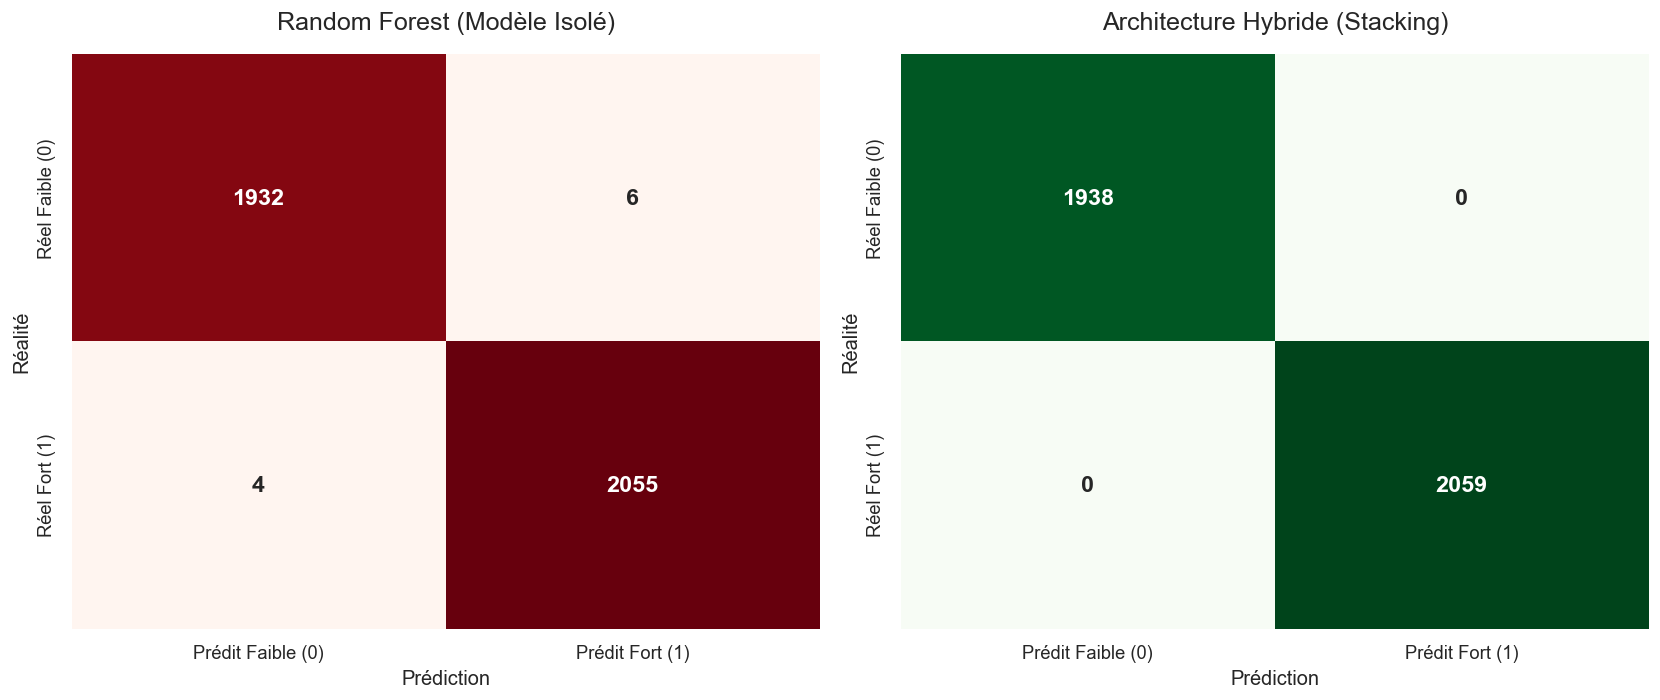

--- ANALYSE DES PERFORMANCES ---
Erreurs Random Forest : 10
Erreurs Modèle Hybride : 0
Gain d'hybridation : Élimination de 10 erreurs de classification.


In [70]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --- 1. Résolution dynamique du chemin ---
current_dir = Path(os.getcwd()).resolve()
BASE_DIR = current_dir

# Remonte jusqu'à trouver le dossier 'datasets'
while not (BASE_DIR / "datasets").exists() and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

CSV_PATH = BASE_DIR / "datasets" / "processed" / "test_results_hybrid.csv"

# --- 2. Chargement des prédictions ---
df_results = pd.read_csv(CSV_PATH)
y_true = df_results['y_true']
y_pred_rf = df_results['y_pred_rf']
y_pred_hybrid = df_results['y_pred_hybrid']

# --- 3. Configuration de la figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matrice : Modèle Isolé (Random Forest)
cm_rf = confusion_matrix(y_true, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False, 
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Random Forest (Modèle Isolé)", fontsize=15, pad=15)
axes[0].set_xlabel("Prédiction", fontsize=12)
axes[0].set_ylabel("Réalité", fontsize=12)
axes[0].set_xticklabels(['Prédit Faible (0)', 'Prédit Fort (1)'])
axes[0].set_yticklabels(['Réel Faible (0)', 'Réel Fort (1)'])

# Matrice : Architecture Hybride (Stacking)
cm_hybrid = confusion_matrix(y_true, y_pred_hybrid)
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("Architecture Hybride (Stacking)", fontsize=15, pad=15)
axes[1].set_xlabel("Prédiction", fontsize=12)
axes[1].set_ylabel("Réalité", fontsize=12)
axes[1].set_xticklabels(['Prédit Faible (0)', 'Prédit Fort (1)'])
axes[1].set_yticklabels(['Réel Faible (0)', 'Réel Fort (1)'])

plt.tight_layout()
plt.show()

# --- 4. Métriques de comparaison ---
erreurs_rf = cm_rf[0,1] + cm_rf[1,0]
erreurs_hyb = cm_hybrid[0,1] + cm_hybrid[1,0]

print("--- ANALYSE DES PERFORMANCES ---")
print(f"Erreurs Random Forest : {erreurs_rf}")
print(f"Erreurs Modèle Hybride : {erreurs_hyb}")
print(f"Gain d'hybridation : Élimination de {erreurs_rf - erreurs_hyb} erreurs de classification.")

### Évaluation Finale : Résolution des Cas Limites par l'Hybridation

La comparaison des matrices de confusion valide la supériorité de l'architecture MLOps face à un modèle d'apprentissage supervisé classique.

* **Les limites du modèle isolé :** Le Random Forest génère 10 erreurs de classification sur l'ensemble de test. Ces erreurs correspondent aux anomalies structurelles ("Faux Forts") où le signal mathématique (entropie, longueur) induit le modèle en erreur.
* **L'apport du Méta-Modèle :** L'architecture hybride (Stacking) élimine les erreurs résiduelles de l'expert classique. En déléguant l'analyse de ces cas complexes aux modèles de Deep Learning (CNN/LSTM), le système corrige simultanément les faux positifs (rejets illégitimes de mots de passe générés) et les faux négatifs (validation de mots de passe humains compromis).

**Conclusion Technique de l'Architecture :**
L'intelligence hybride ne se contente pas d'agréger des statistiques ; elle arbitre les faiblesses individuelles de chaque algorithme. Le pipeline final garantit un filtrage sémantique et structurel robuste, neutralisant les techniques d'ingénierie sociale basées sur l'extension artificielle de la complexité.